# GLM analysis on the main task data [sim01]
It uses nilearn and performs the following steps:
1. Load the data from fmriPrep in BIDS format
2. Iterate on the subjects to:
   1. Select the predictors and confounds for the design matrix
   2. Generate 1st level model
   3. Estimate contrast maps
3. Generate group level maps
4. Extract values for the group ROI from the localizer

In [22]:
# Imports
import os
import glob
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.bids import save_glm_to_bids
from nilearn.glm import threshold_stats_img
from nilearn import plotting
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.image import math_img, load_img
from nilearn.masking import apply_mask

In [23]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
task_label = "UA" # "AA_acq-0500", "AA_acq-0750", "AA_acq-1000", "AA_acq-2500", "UA_acq-0500", "UA_acq-0750", "UA_acq-1000", "UA_acq-2500"
acq_label = '0750'
smoothing_fwhm = 6.0
high_pass_hz = 0.003

In [24]:
# contrast naming
if task_label == "AA":
    contrast_name = "Ambiguous - Static"
    contrast_name_valid = "AmbiguousMinusStatic"
elif task_label == "UA":
    contrast_name = "Unambiguous - Static"
    contrast_name_valid = "UnambiguousMinusStatic"


    # this will now change to and we need to split the models into two
    #contrast_name = "motion - static"
    #contrast_name_valid = "motionMinusStatic"

## 1. Load the data from fmriPrep in BIDS format

In [25]:
# import first level data automatically from fmriPrep derivatives
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    img_filters=[('acq', acq_label)],
    hrf_model="spm",
    noise_model="ar2",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    slice_time_ref=None,
    n_jobs=15,
    derivatives_folder=derivatives_folder,
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/first_level/first_level.py:1029: UserWarning: 'slice_time_ref' provided (0.0) is different from the value found in the BIDS dataset (0.4386666666666667).
Note this may lead to the wrong model specification.
  warn(f"'slice_time_ref' provided ({slice_time_ref}) is different "


## 2. Iterate on the subjects in parallel

In [26]:
from joblib import Parallel, delayed

# Define function for first level analysis
def f(idx):

    # fetch model
    model, imgs, events, confounds = (
        models[idx],
        models_run_imgs[idx],
        models_events[idx],
        models_confounds[idx],
    )

    subject = f"sub-{model.subject_label}"

    print(f"Executing for subject {subject}...")

    # trim confounds
    confounds = confounds[0][['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                          'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                          'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                          'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                          'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                          'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                          'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                          ]]

    # replace NaNs with 0s in confounds
    confounds = confounds.fillna(0)
    
    # Fit and contrasts
    model.fit(imgs, events, confounds)

    z_map = model.compute_contrast(contrast_name, output_type="z_score")
    t_map = model.compute_contrast(contrast_name, output_type="stat")
    beta_map = model.compute_contrast(contrast_name, output_type="effect_size")

    # save maps to disk
    z_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                      f"{subject}_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}.nii.gz"))
    t_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                        f"{subject}_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}.nii.gz"))
    beta_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                            f"{subject}_task-{task_label}_acq-{acq_label}_stat-beta_con-{contrast_name_valid}.nii.gz")) 
    
    # create figure with thresholded map for fun
    clean_map, threshold = threshold_stats_img(
        z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=50
    )

    plotting.plot_glass_brain(
        clean_map,
        colorbar=True,
        threshold=threshold,
        plot_abs=False,
        display_mode="ortho",
        figure=plt.figure(figsize=(10, 4)),
    )

    plt.savefig(os.path.join(
        data_dir,'derivatives','nilearn_glm',
        f"{subject}_task-{task_label}_acq-{acq_label}_plot-z_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.png"
        )
    )

    # Export cluster table
    table = get_clusters_table(z_map, threshold, 50)
    table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm",
                              f"{subject}_task-{task_label}_acq-{acq_label}_table-clusters_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.tsv"),sep='\t')
    
    del model, events, confounds, imgs

# Run in parallel
Parallel(n_jobs=15)(delayed(f)(idx) for idx in range(len(models)))


Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='06', t_r=0.75): 11Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='16', t_r=0.75): 6

Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='02', t_r=0.75): 4
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='21', t_r=0.75): 3
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='11', t_r=0.75): 2
Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='07', t_r=0.75): 13Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=15, no

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/a

Extracting and saving residuals
Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  con

Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)


Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)


Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/gl

Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals
Extracting and saving residuals


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(


Extracting and saving r_square
Extracting and saving residuals
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "Unambiguous - Static" changed to "unambiguousMinusStatic"
  warnings.warn(


Extracting and saving residuals
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square
Extracting and saving r_square


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

## 3. Group level analysis

In [27]:
# List all tmap nii.gz files
tmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}.nii.gz"
    )
)
tmap_files.sort()

# List all zmap nii.gz files
zmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}.nii.gz"
    )
)
zmap_files.sort()

subject_list = [os.path.basename(f).split('_')[0] for f in tmap_files]
subject_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

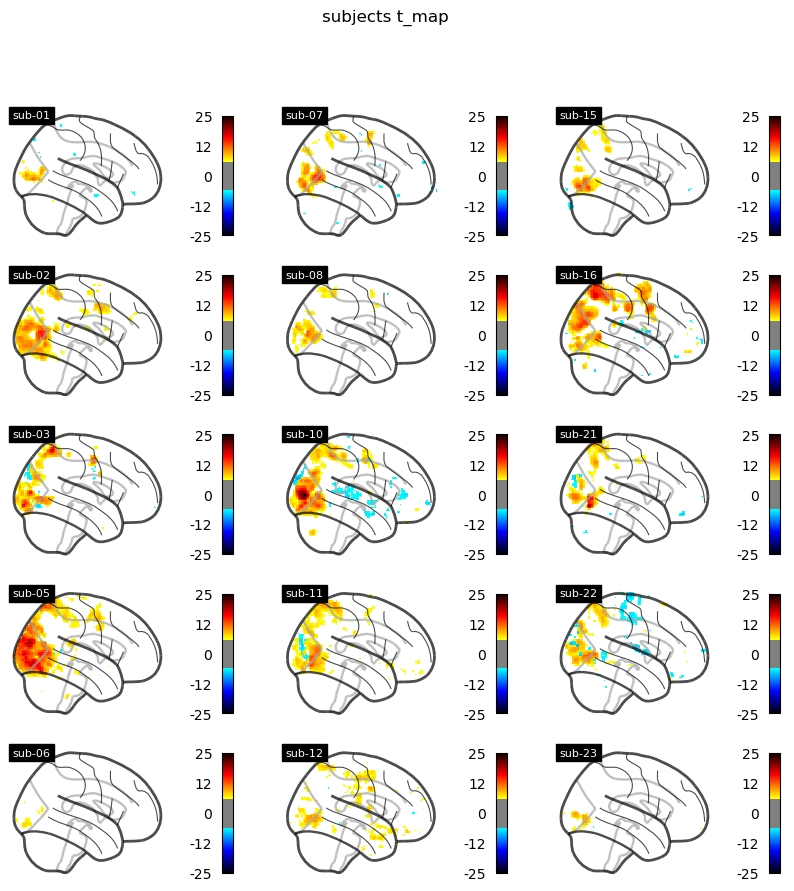

In [28]:
# Plot all subjects
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 10))
for cidx, tmap in enumerate(tmap_files):
    P = plotting.plot_glass_brain(
        tmap,
        colorbar=True,
        threshold=6.0,
        vmax=25,
        axes=axes[cidx % 5, int(cidx / 5)],
        plot_abs=False,
        display_mode="x",
    )
    P.title(subject_list[cidx], size=8)
fig.suptitle("subjects t_map")
plt.show()

In [29]:
# create design matrix for 2nd level
second_level_input = zmap_files
design_matrix_g = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

# define 2nd level model
second_level_model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=20)

second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix_g,
)

# compute contrast (z score map)
z_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
)

# compute contrast (t score map)
t_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="stat",
)

# compute contrast (beta map)
beta_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type='effect_size',
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:382: UserWarning: empty mask
  get_mask_bounds(new_img_like(img, not_mask, affine))


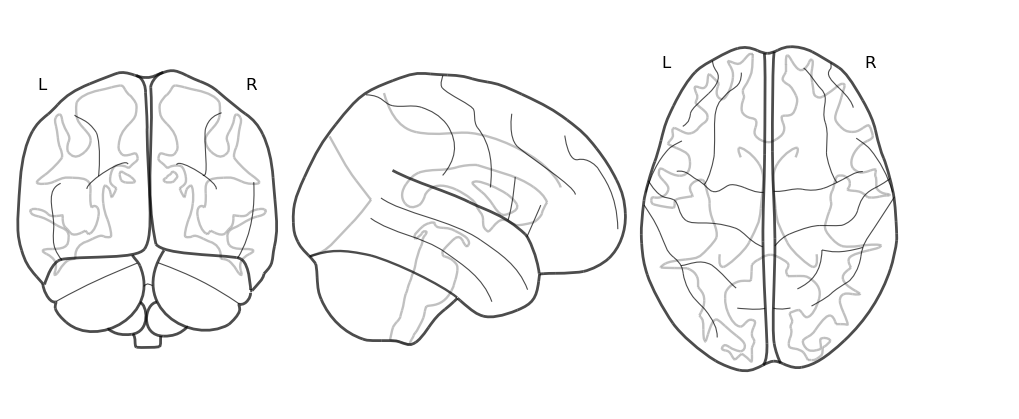

In [30]:
# Threshold zmap and plot it
clean_map_g, threshold_g = threshold_stats_img(
    z_map_g, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)

plotting.plot_glass_brain(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    plot_abs=False,
    display_mode="ortho",
    vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
)

plt.savefig(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                         f"group_task-{task_label}_acq-{acq_label}_plot-z_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.png"))

In [31]:
# Export cluster table
table,cluster_map_g = get_clusters_table(z_map_g, threshold_g, 50,
                                return_label_maps=True)

table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                          f"group_task-{task_label}_acq-{acq_label}_table-clusters_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.tsv"),sep='\t')
#print(table)
#print(table.to_latex())
table


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/reporting/_get_clusters_table.py:338: UserWarning: Attention: No clusters with stat higher than 5.205476006093205
  warnings.warn(


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/matrix_plotting.py:366: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)


Extracting and saving residuals
Extracting and saving r_square


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)


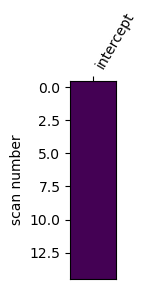

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


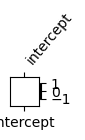

In [32]:
# Save z_map_g, t_map_g, beta_map_g
z_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                                 f"group_task-{task_label}_stat-z_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.nii.gz"))

t_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                                    f"group_task-{task_label}_stat-t_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.nii.gz"))

beta_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                                    f"group_task-{task_label}_stat-beta_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.nii.gz"))

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/_utils/param_validation.py:72: UserWarning: The given float value must not exceed 0.0. But, you have given threshold=5.205476006093205 
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/find_cuts.py:69: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  warnings.warn(



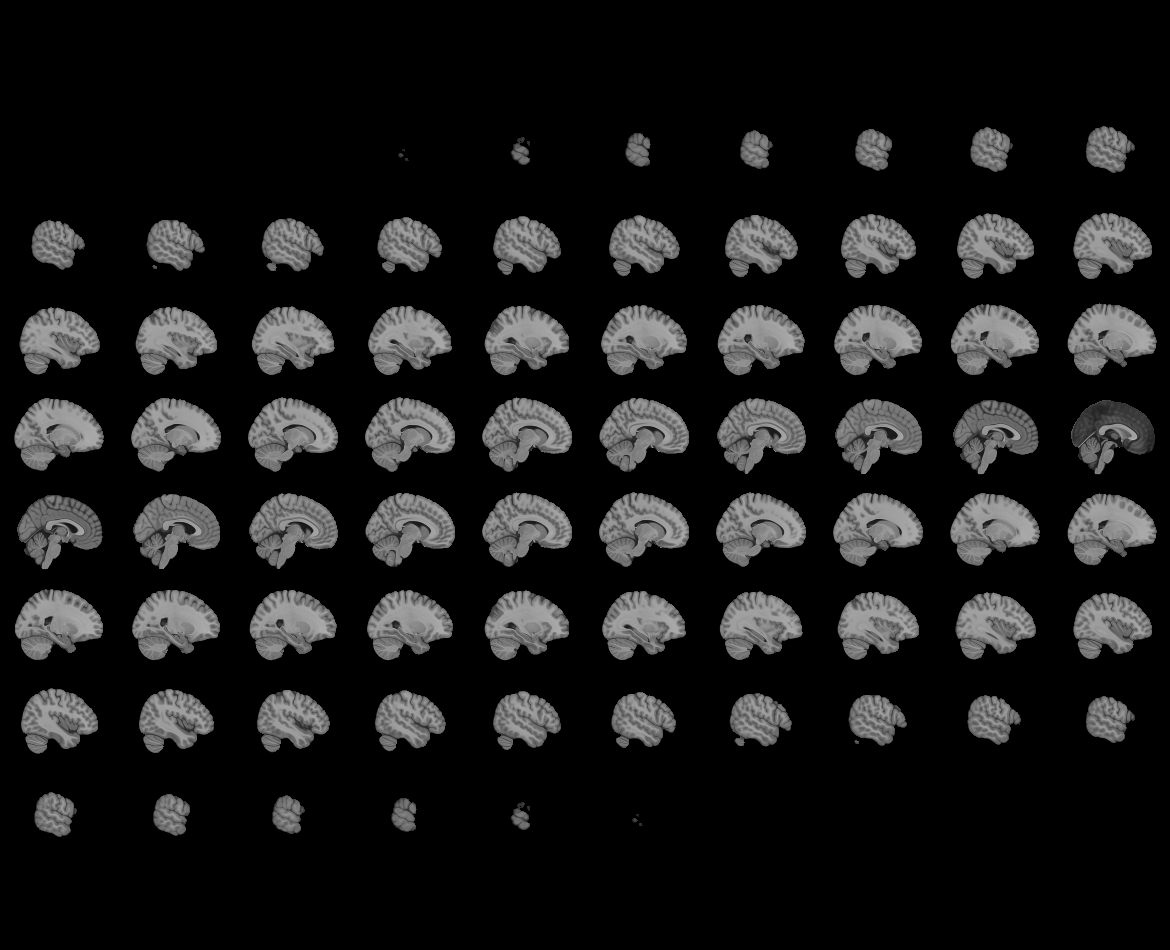
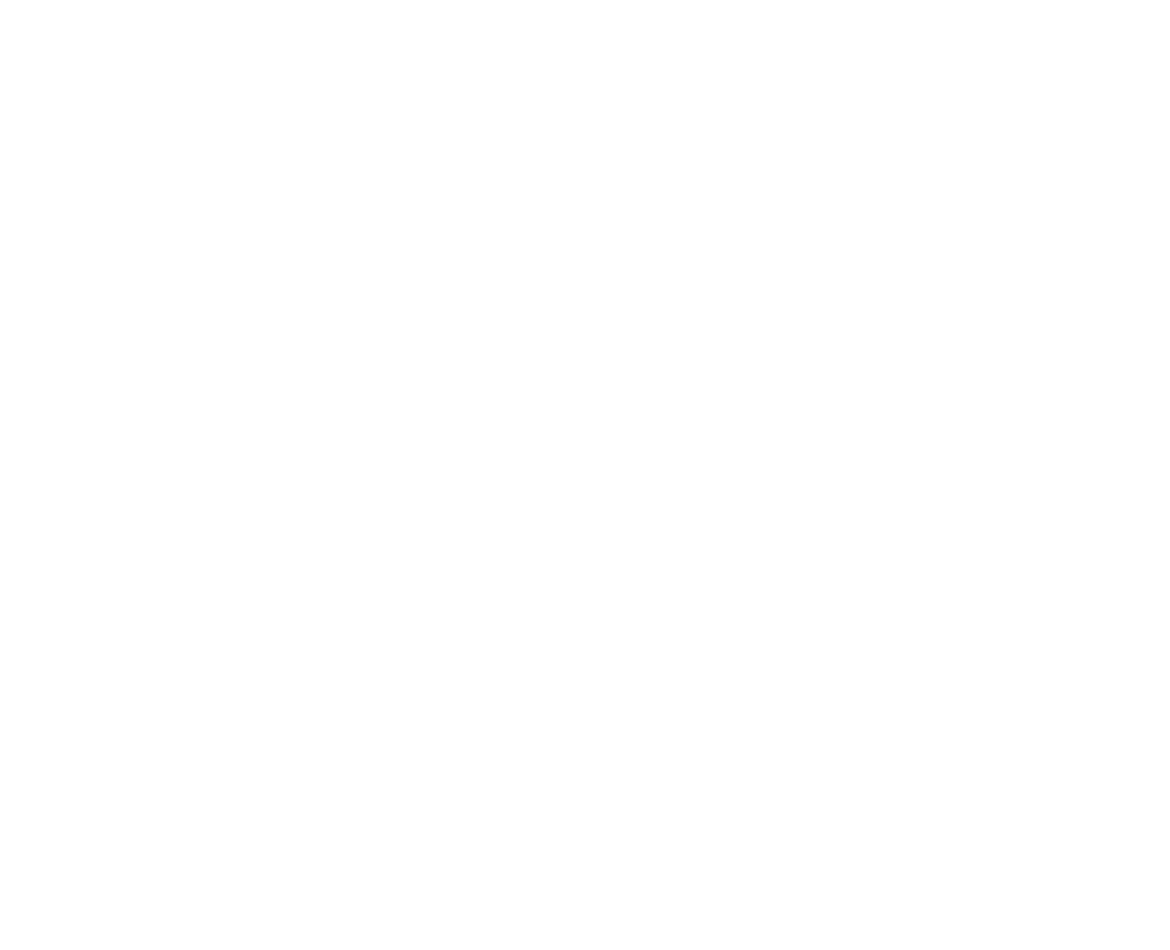

In [33]:
# View map interactively
plotting.view_img(clean_map_g,
         threshold=threshold_g
        )

# ROI analysis

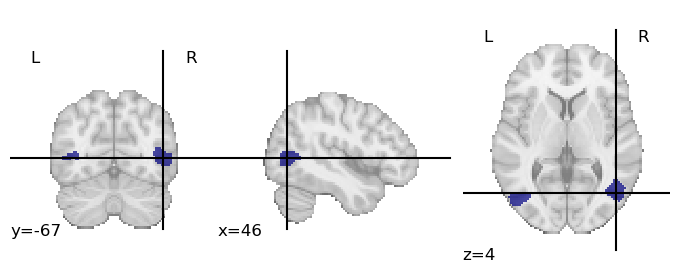

In [34]:
# Load mask from group GLM
mask_hMT = load_img(os.path.join(data_dir,"derivatives","nilearn_glm","group",'mask_hMT.nii.gz'))

plotting.plot_roi(mask_hMT)

In [35]:
# List all tmap nii.gz files
tmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-t_con-{contrast_name_valid}.nii.gz"
    )
)
tmap_files.sort()

# List all zmap nii.gz files
zmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-z_con-{contrast_name_valid}.nii.gz"
    )
)
zmap_files.sort()

# List all beta nii.gz files
beta_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        f"sub-*_task-{task_label}_acq-{acq_label}_stat-beta_con-{contrast_name_valid}.nii.gz"
    )
)
beta_files.sort()

In [36]:
# apply mask to all t maps
T = apply_mask(tmap_files, mask_hMT)
# apply mask to all z maps
Z = apply_mask(zmap_files, mask_hMT)
# apply mask to all beta maps
B = apply_mask(beta_files, mask_hMT)

In [37]:
#mean per subject
MT = np.mean(T,axis=1)
MZ = np.mean(Z,axis=1)
MB = np.mean(B,axis=1)

# export MT as tsv
np.savetxt(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.tsv"),
            MT,delimiter='\t',fmt='%.4f')

# export MZ as tsv
np.savetxt(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.tsv"),
            MZ,delimiter='\t',fmt='%.4f')

# export MB as tsv
np.savetxt(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                        f"group_task-{task_label}_acq-{acq_label}_table-meanTvaluePerSub_con-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50.tsv"),
            MB,delimiter='\t',fmt='%.4f')

